# OpenZL as Zarr Codec Demonstration

In this notebook, we will learn how to train specialized OpenZL compressors and use them to encode Zarr chunks.

## Input Dataset

To show the potential, we will not use synthetic data in this demonstration, but rather real satellite observations from NOAA's GOES-R series.

More precicely, we will use full disk images of the 11.2$\mu$m infrared longwave window band.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import h5netcdf
import s3fs
import zarr
import openzl4zarr

fs = s3fs.S3FileSystem(anon=True)
files = sorted(fs.glob("noaa-goes16/ABI-L1b-RadF/2022/094/*/OR_ABI-L1b-RadF-M6C14_*.nc"))

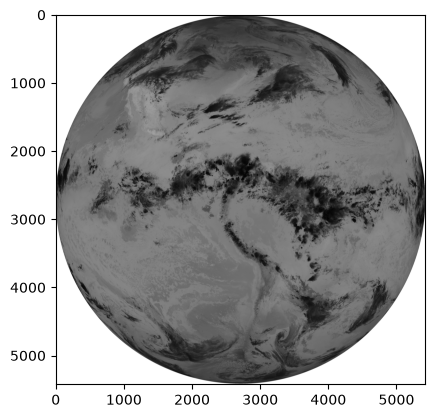

In [2]:
with fs.open(files[0]) as stream, h5netcdf.File(stream) as ds:
    t_attrs = dict(ds["t"].attrs)
    t_dtype = ds["t"].dtype
    img = ds["Rad"][...]
    img_attrs = dict(ds["Rad"].attrs)

plt.imshow(img, cmap="gray")

In [3]:
img_attrs

{'_FillValue': np.int16(4095),
 'long_name': 'ABI L1b Radiances',
 'standard_name': 'toa_outgoing_radiance_per_unit_wavenumber',
 '_Unsigned': 'true',
 'sensor_band_bit_depth': np.int8(12),
 'valid_range': array([   0, 4094], dtype=int16),
 'scale_factor': np.float32(0.049492206),
 'add_offset': np.float32(-1.7187),
 'units': 'mW m-2 sr-1 (cm-1)-1',
 'resolution': 'y: 0.000056 rad x: 0.000056 rad',
 'coordinates': 'band_id band_wavelength t y x',
 'grid_mapping': 'goes_imager_projection',
 'cell_methods': 't: point area: point',
 'ancillary_variables': 'DQF'}

## Reference Array

As a reference, we will create a Zarr array using Zstd compression at level 22 (highest).

In [4]:
dtype = img.dtype
imgshape = img.shape
fill_value = img_attrs["_FillValue"]
shape = (len(files),) + imgshape
chunks = (1, imgshape[0]//12, imgshape[1]//12)
shards = (1,) + imgshape
print(shape, shards, chunks)

(144, 5424, 5424) (1, 5424, 5424) (1, 452, 452)


In [5]:
store = zarr.storage.LocalStore("example.zarr")
try:
    root = zarr.create_group(store)
except zarr.errors.ContainsGroupError:
    root = zarr.open_group(store)

try:
    time = root.create_array(name="time", shape=(len(files),), chunks=(len(files),), compressors=[], dtype=t_dtype)
    time.attrs["long_name"] = t_attrs["long_name"]
    time.attrs["standard_name"] = t_attrs["standard_name"]
    time.attrs["units"] = t_attrs["units"]
except zarr.errors.ContainsArrayError:
    time = root["time"]

try:
    img_zstd = root.create_array(
        name="ABI-L1b-RadF-M6C14-zstd", dimension_names=("time", "y", "x"),
        dtype=dtype, shape=shape, chunks=chunks, shards=shards,
        compressors=[zarr.codecs.ZstdCodec(level=22)], fill_value=fill_value
    )
except zarr.errors.ContainsArrayError:
    img_zstd = root["ABI-L1b-RadF-M6C14-zstd"]

In [6]:
tmp = time[...]
for t, file in enumerate(files):
    print(f"{t}/{len(tmp)}", file, end="\r")
    if (img_zstd[t] == fill_value).all():
        with fs.open(file) as stream, h5netcdf.File(stream) as ds:
            print(f"loading: {t}/{len(tmp)}", end="\r")
            img = ds["Rad"][...]
            tmp[t] = ds["t"][...]
        img_zstd[t, ...] = img
print(f"{len(tmp)}/{len(tmp)}", " " * len(file))
time[...] = tmp

144/144                                                                                                                  


## Global Training

In this section, we train an OpenZL compressor for these data chunks and compress. For more information, see https://openzl.org/getting-started/quick-start/

In [8]:
import pathlib

sampledir = pathlib.Path("global_samples")
sampledir.mkdir(exist_ok=True)

np.random.seed(7)
nsamples = 64
count = sum(1 for _ in sampledir.glob("*.raw"))
nt, nc, nc = img_zstd.shape
side = img_zstd.chunks[1]
nc //= side
while count < nsamples:
    print(f"{count}/{nsamples}", end="\r")
    t = np.random.randint(0, nt)
    j, i = np.random.randint(0, nc, size=2)
    path = sampledir / f"{t}_{j}_{i}.raw"
    if path.is_file():
        continue
    chunk = img_zstd[t, j*side:(j+1)*side, i*side:(i+1)*side]
    if (chunk == fill_value).all():
        continue
    count += 1
    path.write_bytes(chunk.tobytes())
print(f"{nsamples}/{nsamples}")

64/64


Now, we have to train the compressor. We start with a profile corresponding to our data type, which in this case is `le-i16`.

In [9]:
img_zstd.dtype

dtype('<i2')

In [12]:
!../openzl/zli list-profiles

Available profiles:
  -| csv                    = CSV. Pass optional non-comma separator with --profile-arg <char>.
  -| i8                     = Signed 8-bit data
  -| le-i16                 = Little-endian signed 16-bit data
  -| le-i32                 = Little-endian signed 32-bit data
  -| le-i64                 = Little-endian signed 64-bit data
  -| le-u16                 = Little-endian unsigned 16-bit data
  -| le-u32                 = Little-endian unsigned 32-bit data
  -| le-u64                 = Little-endian unsigned 64-bit data
  -| numeric-ml-selector-64 = 64 bit numeric data using ml selectors (Placeholder)
  -| parquet                = Parquet in the canonical format (no compression, plain encoding)
  -| pytorch                = Pytorch model generated from torch.save(). Training is not supported.
  -| sao                    = SAO format from the Silesia corpus
  -| sddl                   = Data that can be parsed using the Simple Data Description Language. Pass a path

In [11]:
!../openzl/zli train --output global-compressor.zlc --use-all-samples --profile le-i16 global_samples/

Using all provided training samples, total size 26150912
Benchmarking untrained compressor...
64 files: 26150912 -> 11422725 (2.29),  57.46 MB/s  660.66 MB/s
[==================================================] Training ACE graph 1 / 1: ACE progress
Trained 1 compressors in 9.325118 minutes (wall time).
Benchmarking trained compressor...
64 files: 26150912 -> 9505636 (2.75),  129.15 MB/s  1087.77 MB/s
Training improved compression ratio by 20.17%


In [13]:
# create a Zarr codec and the corresponding array
codec = openzl4zarr.OpenZLCodec.from_path("global-compressor.zlc")
img_openzl_global = root.create_array(
    name="ABI-L1b-RadF-M6C14-openzl-global", dimension_names=("time", "y", "x"),
    dtype=img_zstd.dtype, shape=img_zstd.shape, chunks=img_zstd.chunks, shards=img_zstd.shards,
    compressors=[codec], fill_value=img_zstd.fill_value
)

In [14]:
# re-compress the data
for t in range(img_zstd.shape[0]//4):
    start = 4*t
    stop = 4*(t+1)
    img_openzl_global[start:stop, :, :] = img_zstd[start:stop, :, :]

In [15]:
arraydir = pathlib.Path("example.zarr/ABI-L1b-RadF-M6C14-zstd/")
zstd_size = sum(path.stat().st_size for path in arraydir.glob("**/*"))
print(f"{zstd_size / 1024**3:.2f} GiB")

3.60 GiB


In [16]:
arraydir = pathlib.Path("example.zarr/ABI-L1b-RadF-M6C14-openzl-global/")
openzl_global_size = sum(path.stat().st_size for path in arraydir.glob("**/*"))
print(f"{openzl_global_size / 1024**3:.2f} GiB")

2.74 GiB


In [56]:
print(f"{(1 - openzl_global_size / zstd_size)*100:.1f}% storage space savings compared to Zstd level 22")

23.8% storage space savings compared to Zstd level 22


Now, we show that we can read the array without compressor.

In [17]:
read_openzl = zarr.open_array(store, path="ABI-L1b-RadF-M6C14-openzl-global")
read_openzl

<Array file://example.zarr/ABI-L1b-RadF-M6C14-openzl-global shape=(144, 5424, 5424) dtype=int16>

In [18]:
read_openzl.metadata

ArrayV3Metadata(shape=(144, 5424, 5424), data_type=Int16(endianness='little'), chunk_grid=RegularChunkGridMetadata(chunk_shape=(1, 5424, 5424)), chunk_key_encoding=DefaultChunkKeyEncoding(separator='/'), fill_value=np.int16(4095), codecs=(ShardingCodec(chunk_shape=(1, 452, 452), codecs=(BytesCodec(endian='little'), OpenZLCodec(compressor=None)), index_codecs=(BytesCodec(endian='little'), Crc32cCodec()), index_location='end', subchunk_write_order='morton'),), attributes={}, dimension_names=('time', 'y', 'x'), zarr_format=3, node_type='array', storage_transformers=(), extra_fields={})

In [19]:
t = np.random.randint(0, nt)
(read_openzl[t] == img_zstd[t]).all()

np.True_

## Regional Training

There is a big difference between chunks that are at the edge of the disk and internal chunks, because a large fraction of the values could be the same.
Since we know in advance where these regions are, we can use different compressors for these regions.

In [42]:
img = img_openzl_global[0]
side = img_zstd.chunks[1]
mask = img == fill_value
tiles = np.lib.stride_tricks.sliding_window_view(mask, (side, side))[::side, ::side]

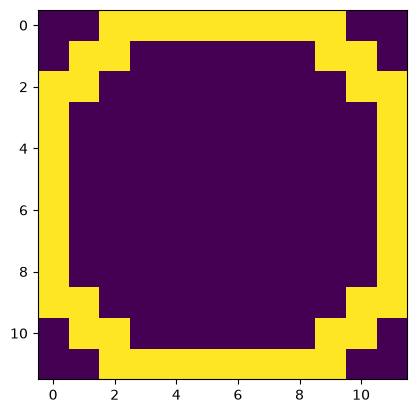

In [43]:
outer = tiles.all(axis=(-2, -1))
inner = np.logical_not(tiles.any(axis=(-2, -1)))
edges = np.logical_xor(np.logical_not(inner), outer)
plt.imshow(edges)

In [44]:
sampledir = pathlib.Path("inner_samples")
sampledir.mkdir(exist_ok=True)

np.random.seed(7)
nsamples = 64
count = sum(1 for _ in sampledir.glob("*.raw"))
nt = img_zstd.shape[0]
jis = np.column_stack(np.nonzero(inner))
while count < nsamples:
    print(f"{count}/{nsamples}", end="\r")
    t = np.random.randint(0, nt)
    k = np.random.randint(0, len(jis))
    j, i = jis[k]
    path = sampledir / f"{t}_{j}_{i}.raw"
    if path.is_file():
        continue
    chunk = img_openzl_global[t, j*side:(j+1)*side, i*side:(i+1)*side]
    if (chunk == fill_value).all():
        continue
    count += 1
    path.write_bytes(chunk.tobytes())
print(f"{nsamples}/{nsamples}")

64/64


In [45]:
!../openzl/zli train --output inner-compressor.zlc --use-all-samples --profile le-i16 inner_samples/

Using all provided training samples, total size 26150912
Benchmarking untrained compressor...
64 files: 26150912 -> 13552292 (1.93),  49.27 MB/s  577.68 MB/s
[==================================================] Training ACE graph 1 / 1: ACE progress
Trained 1 compressors in 6.996144 minutes (wall time).
Benchmarking trained compressor...
64 files: 26150912 -> 11291467 (2.32),  374.09 MB/s  549.80 MB/s
Training improved compression ratio by 20.02%


In [46]:
sampledir = pathlib.Path("edges_samples")
sampledir.mkdir(exist_ok=True)

np.random.seed(7)
nsamples = 64
count = sum(1 for _ in sampledir.glob("*.raw"))
nt = img_zstd.shape[0]
jis = np.column_stack(np.nonzero(edges))
while count < nsamples:
    print(f"{count}/{nsamples}", end="\r")
    t = np.random.randint(0, nt)
    k = np.random.randint(0, len(jis))
    j, i = jis[k]
    path = sampledir / f"{t}_{j}_{i}.raw"
    if path.is_file():
        continue
    chunk = img_openzl_global[t, j*side:(j+1)*side, i*side:(i+1)*side]
    if (chunk == fill_value).all():
        continue
    count += 1
    path.write_bytes(chunk.tobytes())
print(f"{nsamples}/{nsamples}")

64/64


In [47]:
!../openzl/zli train --output edges-compressor.zlc --use-all-samples --profile le-i16 edges_samples/

Using all provided training samples, total size 26150912
Benchmarking untrained compressor...
64 files: 26150912 -> 7703771 (3.39),  76.27 MB/s  906.90 MB/sK
[==================================================] Training ACE graph 1 / 1: ACE progress
Trained 1 compressors in 5.684148 minutes (wall time).
Benchmarking trained compressor...
64 files: 26150912 -> 6352957 (4.12),  159.06 MB/s  1358.13 MB/s
Training improved compression ratio by 21.26%


In [48]:
from openzl4zarr.sharding import OpenZLShardingCodec
from collections import UserDict

class CodecMapping(UserDict):
    def __init__(self, *args, default=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.default = default
    
    def __missing__(self, chunk_coords):
        if self.default is not None:
            return self.default
        raise KeyError(str(chunk_coords))

class CountCodec(openzl4zarr.OpenZLCodec):
    """This is just a wrapper which shows us how often which codec has been used"""
    _encode_hits = 0
    def _encode_sync(self, *args, **kwargs):
        self._encode_hits += 1
        return super()._encode_sync(*args, **kwargs)

    @property
    def hits(self):
        return self._encode_hits

edges_codec = CountCodec.from_path("edges-compressor.zlc")
inner_codec = CountCodec.from_path("inner-compressor.zlc")

codec_mapping = CodecMapping({
    (0, int(j), int(i)): edges_codec
    for j, i  in zip(*np.nonzero(edges))
}, default=inner_codec)

sharding_codec = OpenZLShardingCodec(chunk_shape=img_zstd.chunks, codec_mapping=codec_mapping)

img_openzl_regional = root.create_array(
    name="ABI-L1b-RadF-M6C14-openzl-regional", dimension_names=("time", "y", "x"),
    dtype=img_zstd.dtype, shape=img_zstd.shape, chunks=img_zstd.shards,
    fill_value=img_zstd.fill_value, serializer=sharding_codec, compressors=[]
)

In [49]:
for t in range(img_zstd.shape[0]//4):
    start = 4*t
    stop = 4*(t+1)
    img_openzl_regional[start:stop, :, :] = img_openzl_global[start:stop, :, :]

In [50]:
# check that we actually used different compressors
edges_codec.hits, inner_codec.hits

(6311, 12659)

In [51]:
arraydir = pathlib.Path("example.zarr/ABI-L1b-RadF-M6C14-openzl-global/")
openzl_global_size = sum(path.stat().st_size for path in arraydir.glob("**/*"))
print(f"{openzl_global_size / 1024**3:.2f} GiB")

2.74 GiB


In [57]:
arraydir = pathlib.Path("example.zarr/ABI-L1b-RadF-M6C14-openzl-regional/")
openzl_regional_size = sum(path.stat().st_size for path in arraydir.glob("**/*"))
print(f"{openzl_regional_size / 1024**3:.2f} GiB")

2.72 GiB


In [58]:
print(f"{(1 - openzl_regional_size / openzl_global_size)*100:.1f}% storage space savings compared to global training")

0.8% storage space savings compared to Zstd level 22


Using regional training, we were able to squeeze out another percent. Whether it is worth it is something everyone has to decide for themselves.

## Can we do better?

When it comes to storage savings, likely yes. As a next step, we could cluster the inner chunks and create specialized compressors for these clusters.

Here, we will sketch a method, but leave the implementation to the user:

1. Extend the inner samples
2. Create histogramms of the data as feature vectors.
3. Select a distance metric, e.g. Wasserstain distance. Available in [scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wasserstein_distance.html).
4. Cluster the data, (a small number of clusters shuold be enough). [scikit-learn](https://scikit-learn.org/stable/index.html) could be useful.
5. Train a classification model. Again [scikit-learn](https://scikit-learn.org/stable/index.html) could be useful.
6. Create samples for each cluster and train a corresponding compressor.
7. Write your own `openzl.ext.Selector` (see [OpenZL Python example](https://openzl.org/getting-started/examples/py/quick-start/)) that uses the classification model.
8. Create your new inner compressor.

Before we dive in blindly, we should visually verify that such clusters actually exists.

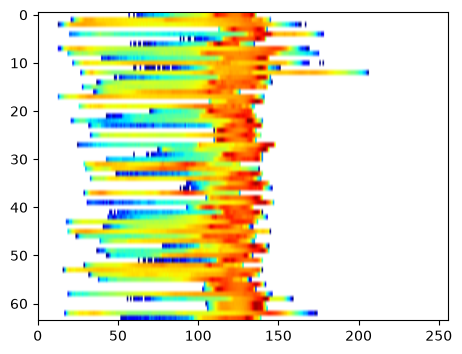

In [111]:
import matplotlib.colors

sampledir = pathlib.Path("inner_samples")
# we know that our data has a maximum value of 2**12 and we want to have 256 bins so the labes fit into an uint8
nbins = 256
steps = 2**12 // nbins
hists = np.array([
    np.bincount(np.fromfile(path, dtype=img.dtype).clip(0, 2**12) // steps, minlength=256)
    for path in sorted(sampledir.iterdir())
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(hists, norm=matplotlib.colors.LogNorm(), cmap="jet")
ax.set_xlim(0, 256)
ax.set_aspect(3)

In [112]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import pairwise_distances
from scipy.stats import wasserstein_distance

dist_matrix = pairwise_distances(hists, metric=wasserstein_distance)
model = AgglomerativeClustering(
    n_clusters=3, metric="precomputed", linkage="average"
)
clusters = model.fit_predict(dist_matrix)

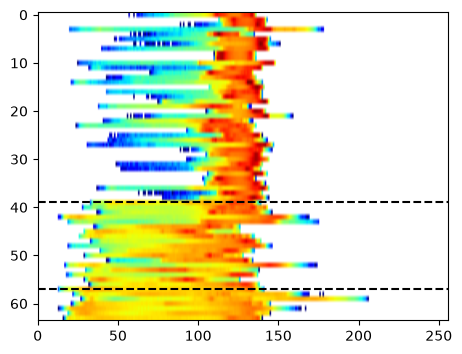

In [113]:
labels, counts = np.unique(clusters, return_counts=True)
sorter = clusters.argsort()

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(hists[sorter], norm=matplotlib.colors.LogNorm(), cmap="jet")
ax.hlines(np.cumsum(counts)[:-1], 0, 256, color="black", linestyle="--")
ax.set_xlim(0, 256)
ax.set_aspect(3)

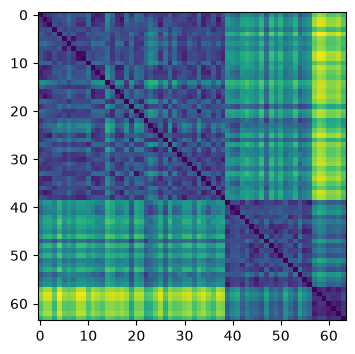

In [114]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(pairwise_distances(hists[sorter], metric=wasserstein_distance))

Happy Coding...